In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


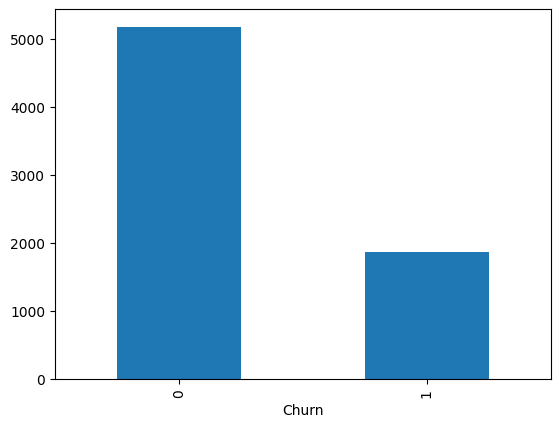

In [6]:
df['Churn']=df['Churn'].map({'No':0, 'Yes':1})
df['Churn'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
numerical_cols=df.select_dtypes(include=['number']).columns.tolist()
print(df[numerical_cols].corr()['Churn'].sort_values(ascending=False))

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn, dtype: float64


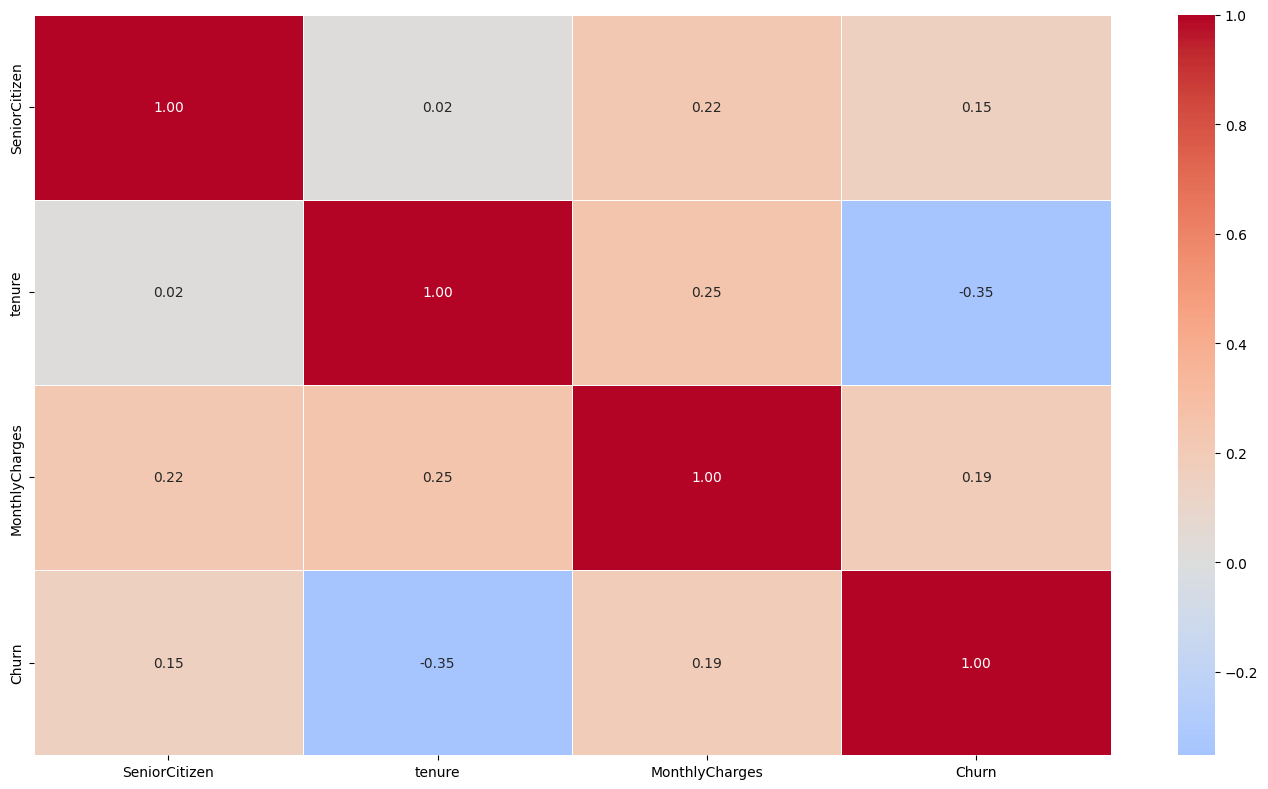

In [8]:
plt.figure(figsize=(14,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f',cmap='coolwarm', center=0, linewidths=0.5)
plt.tight_layout()
plt.show()

In [ ]:
print("Average values by Churn status:")
print(df.groupby('Churn')[numerical_cols].mean().round(2))

Average values by Churn status:
       SeniorCitizen  tenure  MonthlyCharges  Churn
Churn                                              
0               0.13   37.57           61.27    0.0
1               0.25   17.98           74.44    1.0


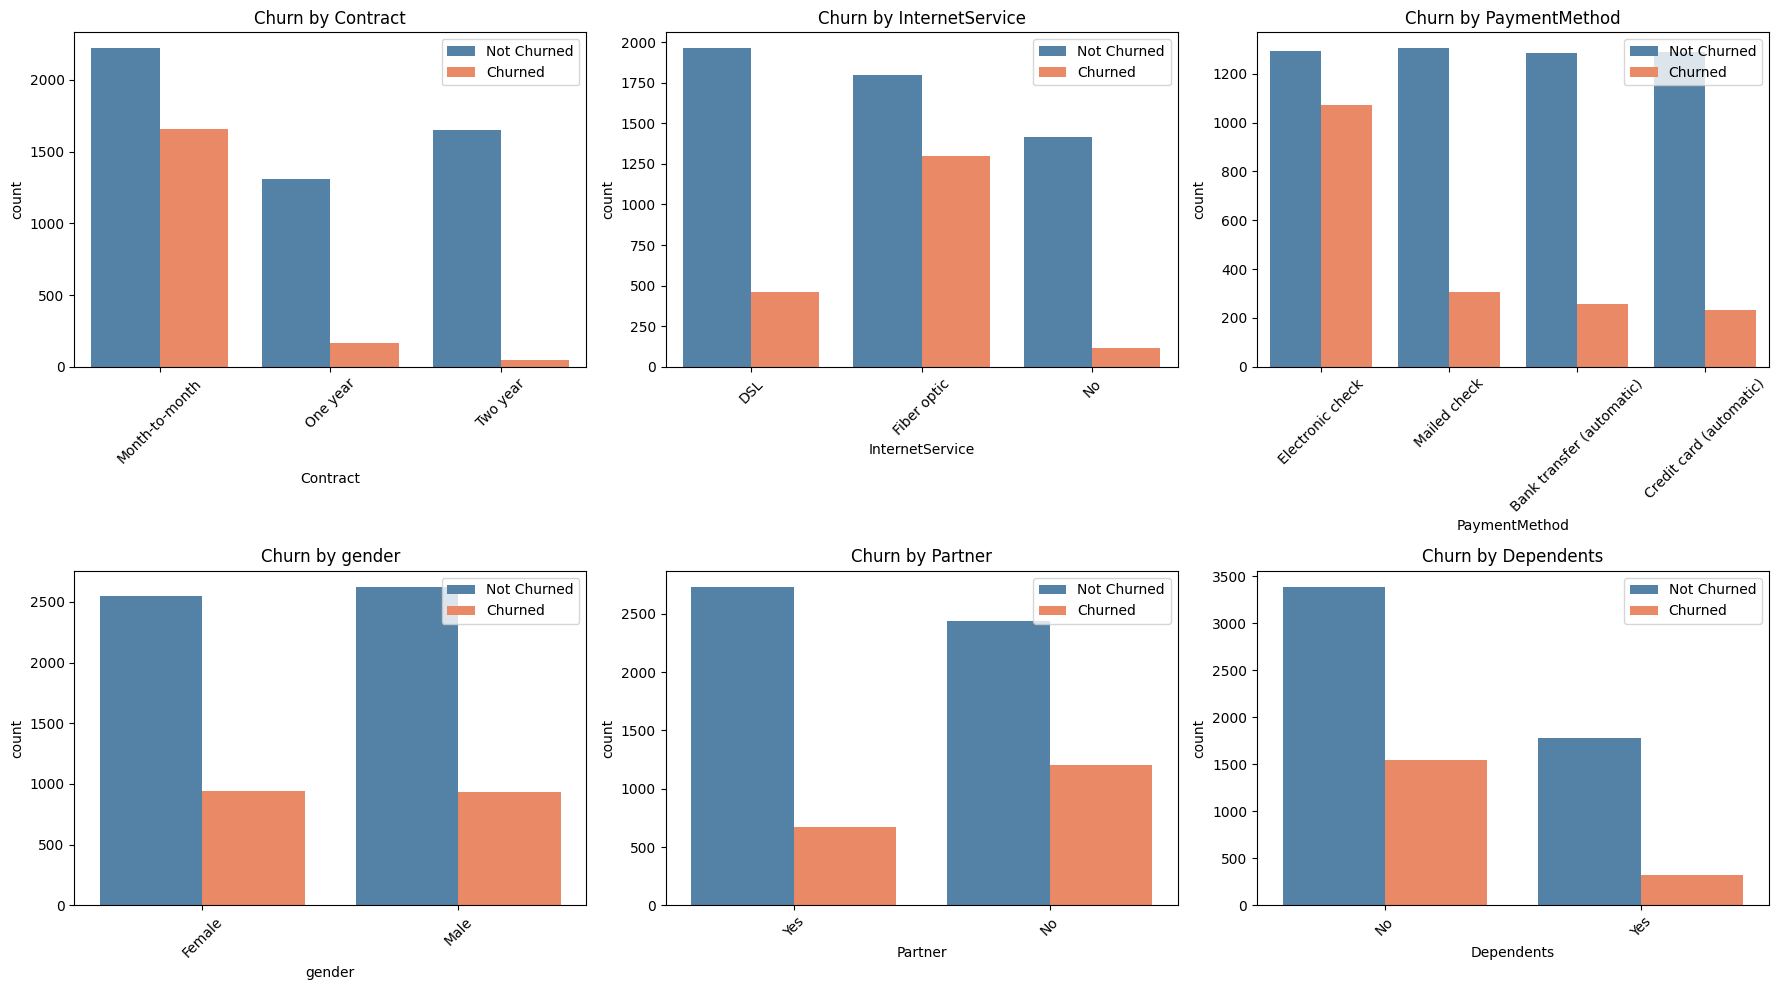

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'gender', 'Partner', 'Dependents']

for idx, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df,
                  palette=['steelblue', 'coral'],
                  ax=axes[idx])
    axes[idx].set_title(f'Churn by {col}')
    axes[idx].legend(['Not Churned', 'Churned'])
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].nunique() < 10:
        print(f"   Values: {df[col].unique()}")
    print()

customerID: 7043 unique values

gender: 2 unique values
   Values: ['Female' 'Male']

SeniorCitizen: 2 unique values
   Values: [0 1]

Partner: 2 unique values
   Values: ['Yes' 'No']

Dependents: 2 unique values
   Values: ['No' 'Yes']

tenure: 73 unique values

PhoneService: 2 unique values
   Values: ['No' 'Yes']

MultipleLines: 3 unique values
   Values: ['No phone service' 'No' 'Yes']

InternetService: 3 unique values
   Values: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: 3 unique values
   Values: ['No' 'Yes' 'No internet service']

OnlineBackup: 3 unique values
   Values: ['Yes' 'No' 'No internet service']

DeviceProtection: 3 unique values
   Values: ['No' 'Yes' 'No internet service']

TechSupport: 3 unique values
   Values: ['No' 'Yes' 'No internet service']

StreamingTV: 3 unique values
   Values: ['No' 'Yes' 'No internet service']

StreamingMovies: 3 unique values
   Values: ['No' 'Yes' 'No internet service']

Contract: 3 unique values
   Values: ['Month-to-month' 'One year'

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

11


In [ ]:
print(df['TotalCharges'].isnull().sum())

0


In [12]:
df=df.drop(columns='customerID')

In [11]:

# Step 3 — Encode internet service columns explicitly
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })

# Step 4 — Encode MultipleLines
df['MultipleLines'] = df['MultipleLines'].map({
    'Yes': 1,
    'No': 0,
    'No phone service': 0
})

# Step 5 — Encode remaining binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                            'Female': 0, 'Male': 1})

# Step 6 — One hot encode multi-category columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract',
                                  'PaymentMethod'], drop_first=True)

# Step 7 — Verify
print("Final shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())
print("\nFirst 5 rows:")
print(df.head())

Final shape: (7043, 25)

All columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Missing values: 0

Data types:
int64      15
bool        7
float64     2
object      1
Name: count, dtype: int64

First 5 rows:
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG       0              0        1           0       1   
1  5575-GNVDE       1              0        0           0      34   
2  3668-QPYBK       1              0        0           0       2   
3  7795-CFOCW       1              0        0           0      45   
4  9237-HQIT

In [ ]:
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")
print("\nAny remaining object columns:")
print(df.select_dtypes(include='object').columns.tolist())
print("\nAny missing values:", df.isnull().sum().sum())

Shape: (7043, 24)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%

Any remaining object columns:
[]

Any missing values: 0


In [ ]:
X=df.drop(columns='Churn')
Y=df['Churn']

In [ ]:
from sklearn.model_selection  import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2,random_state=42)

In [ ]:
print(df['Churn'].nunique())

2


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
dt_model=DecisionTreeClassifier(random_state=42)
dt_cv_accuracy=cross_val_score(dt_model, X_train, Y_train,cv=5, scoring='accuracy')
dt_cv_roc = cross_val_score(dt_model, X_train, Y_train, cv=5, scoring='roc_auc')
dt_cv_f1 = cross_val_score(dt_model, X_train, Y_train, cv=5, scoring='f1')

print("Decision Tree CV Results:")
print(f"  Accuracy : {dt_cv_accuracy.mean():.4f} +/- {dt_cv_accuracy.std():.4f}")
print(f"  ROC-AUC  : {dt_cv_roc.mean():.4f} +/- {dt_cv_roc.std():.4f}")
print(f"  F1 Score : {dt_cv_f1.mean():.4f} +/- {dt_cv_f1.std():.4f}")

dt_model.fit(X_train, Y_train)
train_acc = accuracy_score(Y_train, dt_model.predict(X_train))
test_acc = accuracy_score(Y_test, dt_model.predict(X_test))
print(f"\n  Train Accuracy : {train_acc:.4f}")
print(f"  Test Accuracy  : {test_acc:.4f}")
print(f"  Gap            : {(train_acc - test_acc):.4f}")

Decision Tree CV Results:
  Accuracy : 0.7231 +/- 0.0088
  ROC-AUC  : 0.6545 +/- 0.0082
  F1 Score : 0.4918 +/- 0.0142

  Train Accuracy : 0.9986
  Test Accuracy  : 0.7260
  Gap            : 0.2725


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
param_grid={'n_estimators':[100,200,300],
            'max_depth':[5,10,15,20],
            'min_samples_split': [2,5,10],
            'min_samples_leaf':[1,2,5],
            'class_weight':['balanced',None]}
rf=RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5, scoring='roc_auc',verbose=1,n_jobs=-1)
grid_search.fit(X_train, Y_train)
print('Best Parameters', grid_search.best_params_)
print('Best Score',grid_search.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best Score 0.8423960852906205


In [ ]:
rf_model=RandomForestClassifier(n_estimators=300, max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight='balanced' )
rf_accuracy=cross_val_score(rf_model,X_train,Y_train,cv=5,scoring='accuracy')
rf_ROC=cross_val_score(rf_model,X_train,Y_train,cv=5,scoring='roc_auc')
rf_f1=cross_val_score(rf_model,X_train,Y_train,cv=5,scoring='f1')

print("Random Tree Forest CV Results:")
print(f"  Accuracy : {rf_accuracy.mean():.4f} +/- {rf_accuracy.std():.4f}")
print(f"  ROC-AUC  : {rf_ROC.mean():.4f} +/- {rf_ROC.std():.4f}")
print(f"  F1 Score : {rf_f1.mean():.4f} +/- {rf_f1.std():.4f}")



Random Tree Forest CV Results:
  Accuracy : 0.7670 +/- 0.0063
  ROC-AUC  : 0.8426 +/- 0.0107
  F1 Score : 0.6274 +/- 0.0089


In [ ]:
rf_model.fit(X_train, Y_train)
val=rf_model.predict(X_test)
training_acc=accuracy_score(Y_train,rf_model.predict(X_train))
testing_acc=accuracy_score(Y_test, val)
print('training accuracy',training_acc)
print('testing accuracy: ', testing_acc)
print('Gap: ', training_acc-testing_acc)

training accuracy 0.8205537806176784
testing accuracy:  0.7842441447835344
Gap:  0.03630963583414393


In [ ]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("\nFinal Test Set Evaluation:")
print(f"Accuracy : {accuracy_score(Y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(Y_test, y_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_test, y_pred))


Final Test Set Evaluation:
Accuracy : 0.7842
ROC-AUC  : 0.8659

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1036
           1       0.57      0.79      0.66       373

    accuracy                           0.78      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.78      0.79      1409



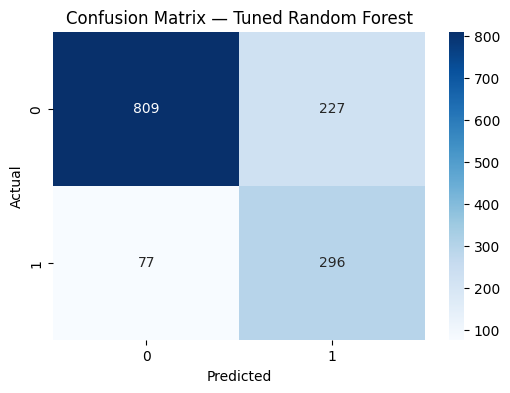

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

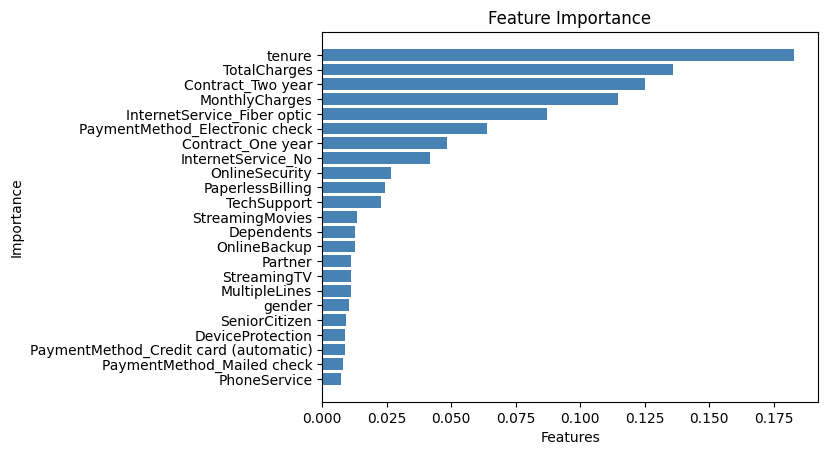

In [ ]:
importance= pd.DataFrame({'Features':X_train.columns,
                          'importance':rf_model.feature_importances_}).sort_values('importance', ascending=True)
plt.barh(importance['Features'],importance['importance'],color='steelblue')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.tight_layout
plt.show()

In [13]:
df['ChargesPerTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

df['ChargesDifference'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

df['TotalStreamingServices'] = (
    (df['StreamingTV'] == 1).astype(int) +
    (df['StreamingMovies'] == 1).astype(int)
)

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['TotalValueServices'] = df[service_cols].sum(axis=1)

df['TotalServices'] = (
    df['PhoneService'] +
    df['MultipleLines'] +
    df['TotalStreamingServices'] +
    df['TotalValueServices']
)

df['IsNewCustomer'] = (df['tenure'] < 6).astype(int)
df['IsLoyalCustomer'] = (df['tenure'] > 24).astype(int)

print("New shape with engineered features:", df.shape)
print("\nNew columns added:")
new_cols = ['ChargesPerTenure', 'ChargesDifference', 'TotalStreamingServices',
            'TotalValueServices', 'TotalServices', 'IsNewCustomer', 'IsLoyalCustomer']
print(new_cols)

New shape with engineered features: (7043, 31)

New columns added:
['ChargesPerTenure', 'ChargesDifference', 'TotalStreamingServices', 'TotalValueServices', 'TotalServices', 'IsNewCustomer', 'IsLoyalCustomer']


In [14]:

cols_to_drop = [

    'StreamingTV',
    'StreamingMovies',


    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',


    'gender',
    'PhoneService',
    'PaymentMethod_Mailed check',
    'PaymentMethod_Credit card (automatic)',
]

df_engineered = df.copy()
df_engineered = df_engineered.drop(columns=cols_to_drop)

print("Shape before dropping:", df.shape)
print("Shape after dropping:", df_engineered.shape)
print("\nRemaining columns:")
print(df_engineered.columns.tolist())

Shape before dropping: (7043, 31)
Shape after dropping: (7043, 21)

Remaining columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Electronic check', 'ChargesPerTenure', 'ChargesDifference', 'TotalStreamingServices', 'TotalValueServices', 'TotalServices', 'IsNewCustomer', 'IsLoyalCustomer']


In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
X_new = df.drop(columns=['Churn'])
y_new = df['Churn']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)


best_rf_new = RandomForestClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


cv_roc_new = cross_val_score(best_rf_new, X_train_new, y_train_new,
                              cv=5, scoring='roc_auc')
cv_f1_new = cross_val_score(best_rf_new, X_train_new, y_train_new,
                             cv=5, scoring='f1')
cv_acc_new = cross_val_score(best_rf_new, X_train_new, y_train_new,
                              cv=5, scoring='accuracy')

print("Tuned RF WITH Engineered Features:")
print(f"  Accuracy : {cv_acc_new.mean():.4f} +/- {cv_acc_new.std():.4f}")
print(f"  ROC-AUC  : {cv_roc_new.mean():.4f} +/- {cv_roc_new.std():.4f}")
print(f"  F1 Score : {cv_f1_new.mean():.4f} +/- {cv_f1_new.std():.4f}")

Tuned RF WITH Engineered Features:
  Accuracy : 0.7760 +/- 0.0211
  ROC-AUC  : 0.8436 +/- 0.0122
  F1 Score : 0.6330 +/- 0.0266


In [20]:
from sklearn.metrics import roc_auc_score, classification_report
best_rf_new.fit(X_train_new, y_train_new)
y_pred_new = best_rf_new.predict(X_test_new)
y_proba_new = best_rf_new.predict_proba(X_test_new)[:, 1]

print("\nFinal Test Set — WITH Engineered Features:")
print(f"  Accuracy : {accuracy_score(y_test_new, y_pred_new):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_new, y_proba_new):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_new, y_pred_new))


Final Test Set — WITH Engineered Features:
  Accuracy : 0.7651
  ROC-AUC  : 0.8443

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [21]:
print("=" * 55)
print("FINAL COMPARISON")
print("=" * 55)
print(f"{'Metric':<20} {'Without FE':>15} {'With FE':>15}")
print("-" * 55)
print(f"{'Test Accuracy':<20} {'0.7842':>15} {accuracy_score(y_test_new, y_pred_new):>15.4f}")
print(f"{'Test ROC-AUC':<20} {'0.8659':>15} {roc_auc_score(y_test_new, y_proba_new):>15.4f}")
print(f"{'CV ROC-AUC':<20} {'0.8424':>15} {cv_roc_new.mean():>15.4f}")
print(f"{'CV F1':<20} {'0.6281':>15} {cv_f1_new.mean():>15.4f}")
print("=" * 55)

FINAL COMPARISON
Metric                    Without FE         With FE
-------------------------------------------------------
Test Accuracy                 0.7842          0.7651
Test ROC-AUC                  0.8659          0.8443
CV ROC-AUC                    0.8424          0.8436
CV F1                         0.6281          0.6330
